<a href="https://colab.research.google.com/github/shanu9540/Demofile/blob/main/2nd_task_for_data_sci.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Image 'sample_image.jpg' not found. Creating a sample gradient image...
Sample image created as 'sample_image.jpg'


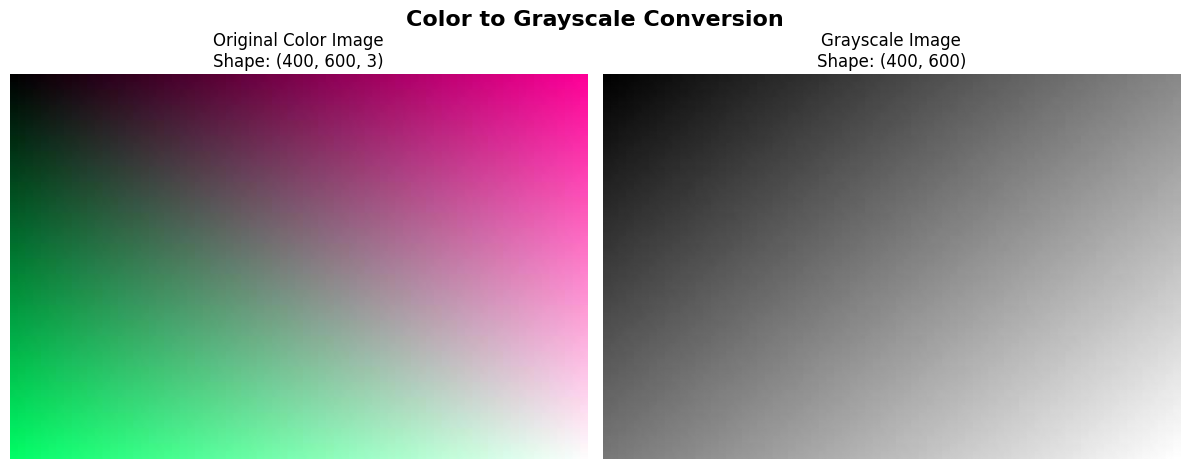

Processing all image versions...


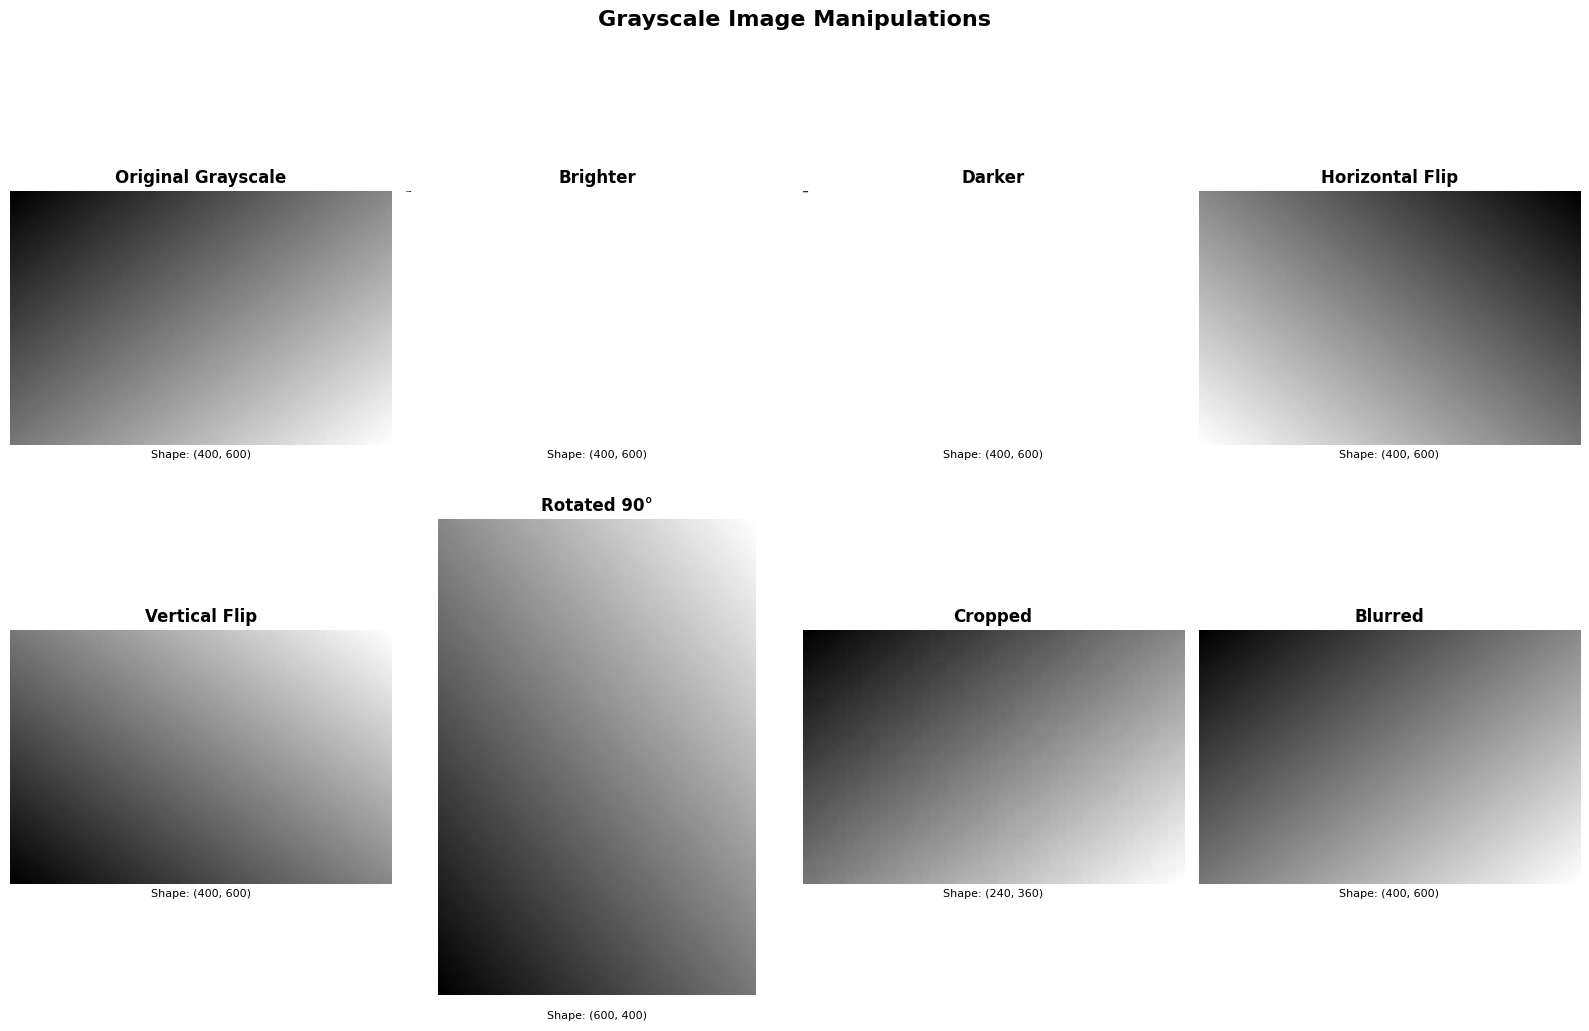


IMAGE PROCESSING SUMMARY
Original image shape: (400, 600, 3)
Grayscale image shape: (400, 600)
Pixel value range: 0.000 - 253.000
Mean pixel value: 126.787
Standard deviation: 52.179

NUMPY OPERATIONS DEMONSTRATION
Original 5x5 image:
[[0.         0.04166667 0.08333333 0.125      0.16666667]
 [0.20833333 0.25       0.29166667 0.33333333 0.375     ]
 [0.41666667 0.45833333 0.5        0.54166667 0.58333333]
 [0.625      0.66666667 0.70833333 0.75       0.79166667]
 [0.83333333 0.875      0.91666667 0.95833333 1.        ]]
Shape: (5, 5)

--- Matrix Operations ---
Transpose (matrix rotation):
[[0.         0.20833333 0.41666667 0.625      0.83333333]
 [0.04166667 0.25       0.45833333 0.66666667 0.875     ]
 [0.08333333 0.29166667 0.5        0.70833333 0.91666667]
 [0.125      0.33333333 0.54166667 0.75       0.95833333]
 [0.16666667 0.375      0.58333333 0.79166667 1.        ]]

Flatten (convert to 1D):
[0.         0.04166667 0.08333333 0.125      0.16666667 0.20833333
 0.25       0.29166

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import os

class GrayscaleImageManipulator:
    def __init__(self, image_path):
        """
        Initialize the image manipulator with an image.

        Args:
            image_path (str): Path to the image file
        """
        self.original_image = imread(image_path)
        self.grayscale_image = None
        self.processed_images = {}

    def convert_to_grayscale(self):
        """
        Convert RGB image to grayscale by averaging the three channels.
        For RGB images, shape is (height, width, 3)
        For RGBA images, shape is (height, width, 4) - we take first 3 channels
        """
        # Check if image has alpha channel
        if self.original_image.shape[-1] == 4:
            rgb_image = self.original_image[:, :, :3]
        else:
            rgb_image = self.original_image

        # Method 1: Simple average of RGB channels
        self.grayscale_image = np.mean(rgb_image, axis=2)

        # Method 2: Using dot product with luminance weights (more accurate to human perception)
        # luminance_weights = np.array([0.2989, 0.5870, 0.1140])
        # self.grayscale_image = np.dot(rgb_image, luminance_weights)

        return self.grayscale_image

    def adjust_brightness(self, image, value):
        """
        Adjust brightness by adding a constant value to all pixels.

        Args:
            image: Input image array
            value: Brightness adjustment value (positive = brighter, negative = darker)
        """
        brightened = image + value
        # Clip values to valid range [0, 1] for float images or [0, 255] for uint8
        if image.dtype == np.uint8:
            brightened = np.clip(brightened, 0, 255)
        else:
            brightened = np.clip(brightened, 0, 1)
        return brightened

    def flip_horizontal(self, image):
        """Flip image horizontally (left-right mirror)"""
        return np.fliplr(image)

    def flip_vertical(self, image):
        """Flip image vertically (top-bottom mirror)"""
        return np.flipud(image)

    def rotate_90(self, image, k=1):
        """Rotate image by 90 degrees clockwise k times"""
        return np.rot90(image, k=k)

    def crop_image(self, image, top, bottom, left, right):
        """
        Crop image using array slicing.

        Args:
            image: Input image array
            top: Starting row index
            bottom: Ending row index
            left: Starting column index
            right: Ending column index
        """
        return image[top:bottom, left:right]

    def apply_blur(self, image, kernel_size=3):
        """
        Apply simple blur effect by averaging pixel values with neighbors.

        Args:
            image: Input image array
            kernel_size: Size of the blur kernel (must be odd)
        """
        # Create a copy to avoid modifying the original
        blurred = image.copy()
        height, width = image.shape[:2]

        # Calculate padding size
        pad = kernel_size // 2

        # Pad the image to handle edges
        if len(image.shape) == 2:  # Grayscale image
            padded = np.pad(image, pad, mode='edge')

            # Apply blur using nested loops (simple approach)
            for i in range(height):
                for j in range(width):
                    # Extract the kernel neighborhood
                    neighborhood = padded[i:i+kernel_size, j:j+kernel_size]
                    # Replace pixel with average of neighborhood
                    blurred[i, j] = np.mean(neighborhood)
        else:  # Color image
            padded = np.pad(image, ((pad, pad), (pad, pad), (0, 0)), mode='edge')

            for i in range(height):
                for j in range(width):
                    for c in range(image.shape[2]):
                        neighborhood = padded[i:i+kernel_size, j:j+kernel_size, c]
                        blurred[i, j, c] = np.mean(neighborhood)

        return blurred

    def process_all_versions(self, brightness_value=0.2, crop_coords=None):
        """
        Process the image to create all versions.

        Args:
            brightness_value: Value to adjust brightness
            crop_coords: Tuple (top, bottom, left, right) for cropping
        """
        if self.grayscale_image is None:
            self.convert_to_grayscale()

        # Store all processed versions
        self.processed_images['Original Grayscale'] = self.grayscale_image
        self.processed_images['Brighter'] = self.adjust_brightness(self.grayscale_image, brightness_value)
        self.processed_images['Darker'] = self.adjust_brightness(self.grayscale_image, -brightness_value)
        self.processed_images['Horizontal Flip'] = self.flip_horizontal(self.grayscale_image)
        self.processed_images['Vertical Flip'] = self.flip_vertical(self.grayscale_image)
        self.processed_images['Rotated 90°'] = self.rotate_90(self.grayscale_image, 1)

        # Crop image (default: crop 20% from each side if not specified)
        if crop_coords is None:
            h, w = self.grayscale_image.shape
            crop_coords = (h//5, 4*h//5, w//5, 4*w//5)

        self.processed_images['Cropped'] = self.crop_image(self.grayscale_image, *crop_coords)
        self.processed_images['Blurred'] = self.apply_blur(self.grayscale_image, kernel_size=5)

    def display_all_versions(self):
        """Display all processed image versions side by side"""
        num_images = len(self.processed_images)
        fig, axes = plt.subplots(2, 4, figsize=(16, 10))
        axes = axes.flatten()

        for idx, (title, image) in enumerate(self.processed_images.items()):
            axes[idx].imshow(image, cmap='gray' if len(image.shape) == 2 else None)
            axes[idx].set_title(title, fontsize=12, fontweight='bold')
            axes[idx].axis('off')

            # Add shape information
            shape_text = f"Shape: {image.shape}"
            axes[idx].text(0.5, -0.05, shape_text, transform=axes[idx].transAxes,
                          ha='center', fontsize=8)

        # Hide any unused subplots
        for idx in range(len(self.processed_images), len(axes)):
            axes[idx].axis('off')

        plt.suptitle('Grayscale Image Manipulations', fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

    def display_comparison(self):
        """Display original color and grayscale comparison"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

        # Handle images with alpha channel
        if self.original_image.shape[-1] == 4:
            display_image = self.original_image[:, :, :3]
        else:
            display_image = self.original_image

        ax1.imshow(display_image)
        ax1.set_title(f'Original Color Image\nShape: {display_image.shape}', fontsize=12)
        ax1.axis('off')

        ax2.imshow(self.grayscale_image, cmap='gray')
        ax2.set_title(f'Grayscale Image\nShape: {self.grayscale_image.shape}', fontsize=12)
        ax2.axis('off')

        plt.suptitle('Color to Grayscale Conversion', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

# Main execution
def main():
    # Specify the path to your image
    # You can use any image file path
    image_path = "sample_image.jpg"  # Change this to your image path

    # Check if image exists, if not create a sample
    if not os.path.exists(image_path):
        print(f"Image '{image_path}' not found. Creating a sample gradient image...")
        # Create a sample gradient image for demonstration
        sample_image = np.zeros((400, 600, 3))
        for i in range(400):
            for j in range(600):
                sample_image[i, j] = [j/600, i/400, (i+j)/(1000)]
        plt.imsave(image_path, sample_image)
        print(f"Sample image created as '{image_path}'")

    try:
        # Create manipulator instance
        manipulator = GrayscaleImageManipulator(image_path)

        # Convert to grayscale
        manipulator.convert_to_grayscale()

        # Display original vs grayscale
        manipulator.display_comparison()

        # Process all versions
        print("Processing all image versions...")
        manipulator.process_all_versions(brightness_value=0.2)

        # Display all versions
        manipulator.display_all_versions()

        # Print additional information
        print("\n" + "="*50)
        print("IMAGE PROCESSING SUMMARY")
        print("="*50)
        print(f"Original image shape: {manipulator.original_image.shape}")
        print(f"Grayscale image shape: {manipulator.grayscale_image.shape}")
        print(f"Pixel value range: {manipulator.grayscale_image.min():.3f} - {manipulator.grayscale_image.max():.3f}")
        print(f"Mean pixel value: {np.mean(manipulator.grayscale_image):.3f}")
        print(f"Standard deviation: {np.std(manipulator.grayscale_image):.3f}")

    except Exception as e:
        print(f"Error processing image: {e}")
        print("\nTroubleshooting tips:")
        print("1. Make sure the image file exists and is not corrupted")
        print("2. Supported formats: JPG, PNG, BMP")
        print("3. For web images, download them first using a web browser")

# Additional example: Using NumPy operations directly
def numpy_image_operations_demo():
    """Demonstrate low-level NumPy operations on images"""
    print("\n" + "="*50)
    print("NUMPY OPERATIONS DEMONSTRATION")
    print("="*50)

    # Create a simple 5x5 grayscale image (simulating a small image)
    small_image = np.arange(25).reshape(5, 5) / 24.0  # Values from 0 to 1
    print("Original 5x5 image:")
    print(small_image)
    print(f"Shape: {small_image.shape}")

    # Matrix operations
    print("\n--- Matrix Operations ---")
    print("Transpose (matrix rotation):")
    print(small_image.T)

    print("\nFlatten (convert to 1D):")
    print(small_image.flatten())

    print("\nReshape (convert to different dimensions):")
    print(small_image.reshape(25, 1))

    # Statistical operations
    print("\n--- Statistical Operations ---")
    print(f"Mean: {np.mean(small_image):.3f}")
    print(f"Median: {np.median(small_image):.3f}")
    print(f"Standard deviation: {np.std(small_image):.3f}")
    print(f"Min: {np.min(small_image):.3f}")
    print(f"Max: {np.max(small_image):.3f}")

    # Arithmetic operations
    print("\n--- Arithmetic Operations ---")
    print("Add 0.3 (brightness increase):")
    print(np.clip(small_image + 0.3, 0, 1))

    print("\nMultiply by 1.5 (contrast increase):")
    print(np.clip(small_image * 1.5, 0, 1))

    print("\nPower (gamma correction):")
    print(small_image ** 2)  # Darkens the image

if __name__ == "__main__":
    main()
    numpy_image_operations_demo()